# Sigma Parameter Research

Understanding the physical meaning and valid ranges for the sigma parameter in LogNormalFractalCube generation.

## Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Setup paths
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root / 'src'))
sys.path.insert(0, str(project_root / 'src' / 'pyFC_lib'))

from pyFC.mathtools import LogNormalPDF

print(f"Project root: {project_root}")

Project root: c:\Users\sedig\Documents\cnn_astro


## 1. Understanding Sigma in LogNormal Distribution

In pyFC, the LogNormalFractalCube uses a lognormal distribution with parameters:
- **mu** (mean): The mean of the lognormal distribution
- **sigma**: The standard deviation of the lognormal distribution

The underlying Gaussian has parameters mu_g and sigma_g that are related to mu and sigma.

In [2]:
# Test different sigma values with fixed mu=1
mu_fixed = 1.0
sigma_values = np.array([0.1, 0.5, 1.0, 2.0, 2.236, 3.0, 5.0, 10.0])

results = []
for sigma in sigma_values:
    try:
        ln = LogNormalPDF(mu=mu_fixed, sigma=sigma, gstat=False)
        results.append({
            'sigma_ln': sigma,
            'mu_g': ln.mu_g,
            'sigma_g': ln.sigma_g,
            'skew': ln.skew,
            'kurt': ln.kurt,
            'mode': ln.mode,
            'median': ln.median,
            'flatness': ln.flatness
        })
    except Exception as e:
        print(f"Error with sigma={sigma}: {e}")

# Display results
for r in results:
    print(f"\nsigma_ln={r['sigma_ln']:.3f}:")
    print(f"  Gaussian: mu_g={r['mu_g']:.4f}, sigma_g={r['sigma_g']:.4f}")
    print(f"  Mode={r['mode']:.4f}, Median={r['median']:.4f}")
    print(f"  Skewness={r['skew']:.4f}, Kurtosis={r['kurt']:.4f}")
    print(f"  Flatness={r['flatness']:.4f}")


sigma_ln=0.100:
  Gaussian: mu_g=-0.0050, sigma_g=0.0998
  Mode=0.9852, Median=0.9950
  Skewness=nan, Kurtosis=0.1615
  Flatness=6.1615

sigma_ln=0.500:
  Gaussian: mu_g=-0.1116, sigma_g=0.4724
  Mode=0.7155, Median=0.8944
  Skewness=nan, Kurtosis=5.0352
  Flatness=11.0352

sigma_ln=1.000:
  Gaussian: mu_g=-0.3466, sigma_g=0.8326
  Mode=0.3536, Median=0.7071
  Skewness=nan, Kurtosis=38.0000
  Flatness=44.0000

sigma_ln=2.000:
  Gaussian: mu_g=-0.8047, sigma_g=1.2686
  Mode=0.0894, Median=0.4472
  Skewness=5.4647, Kurtosis=944.0000
  Flatness=950.0000

sigma_ln=2.236:
  Gaussian: mu_g=-0.8959, sigma_g=1.3385
  Mode=0.0680, Median=0.4083
  Skewness=7.1180, Kurtosis=1829.6608
  Flatness=1835.6608

sigma_ln=3.000:
  Gaussian: mu_g=-1.1513, sigma_g=1.5174
  Mode=0.0316, Median=0.3162
  Skewness=13.6957, Kurtosis=12294.0000
  Flatness=12300.0000

sigma_ln=5.000:
  Gaussian: mu_g=-1.6290, sigma_g=1.8050
  Mode=0.0075, Median=0.1961
  Skewness=42.0755, Kurtosis=494150.0000
  Flatness=494156.0

c:\Users\sedig\Documents\cnn_astro\src\pyFC_lib\pyFC\mathtools.py:141: RuntimeWarning: invalid value encountered in sqrt
  return (np.exp(s*s) + 2)*np.sqrt(s*s - 1)


## 2. Physical Constraints on Sigma

### a) Mathematical Constraints
For a lognormal distribution to be valid:
- sigma > 0 (standard deviation must be positive)
- No upper limit mathematically, but practical limits exist

### b) Coefficient of Variation
The coefficient of variation (CV = sigma/mu) controls the spread:

In [3]:
# Analyze coefficient of variation
cv_values = []
for r in results:
    cv = r['sigma_ln'] / mu_fixed
    cv_values.append(cv)
    print(f"sigma={r['sigma_ln']:.3f}: CV = {cv:.3f} (spread = {cv*100:.1f}% of mean)")

sigma=0.100: CV = 0.100 (spread = 10.0% of mean)
sigma=0.500: CV = 0.500 (spread = 50.0% of mean)
sigma=1.000: CV = 1.000 (spread = 100.0% of mean)
sigma=2.000: CV = 2.000 (spread = 200.0% of mean)
sigma=2.236: CV = 2.236 (spread = 223.6% of mean)
sigma=3.000: CV = 3.000 (spread = 300.0% of mean)
sigma=5.000: CV = 5.000 (spread = 500.0% of mean)
sigma=10.000: CV = 10.000 (spread = 1000.0% of mean)


## 3. Distribution Shape Analysis

c:\Users\sedig\Documents\cnn_astro\src\pyFC_lib\pyFC\mathtools.py:99: RuntimeWarning: divide by zero encountered in log
  return np.exp(-(np.log(x) - m)**2/(2*s**2))/\
c:\Users\sedig\Documents\cnn_astro\src\pyFC_lib\pyFC\mathtools.py:99: RuntimeWarning: invalid value encountered in divide
  return np.exp(-(np.log(x) - m)**2/(2*s**2))/\


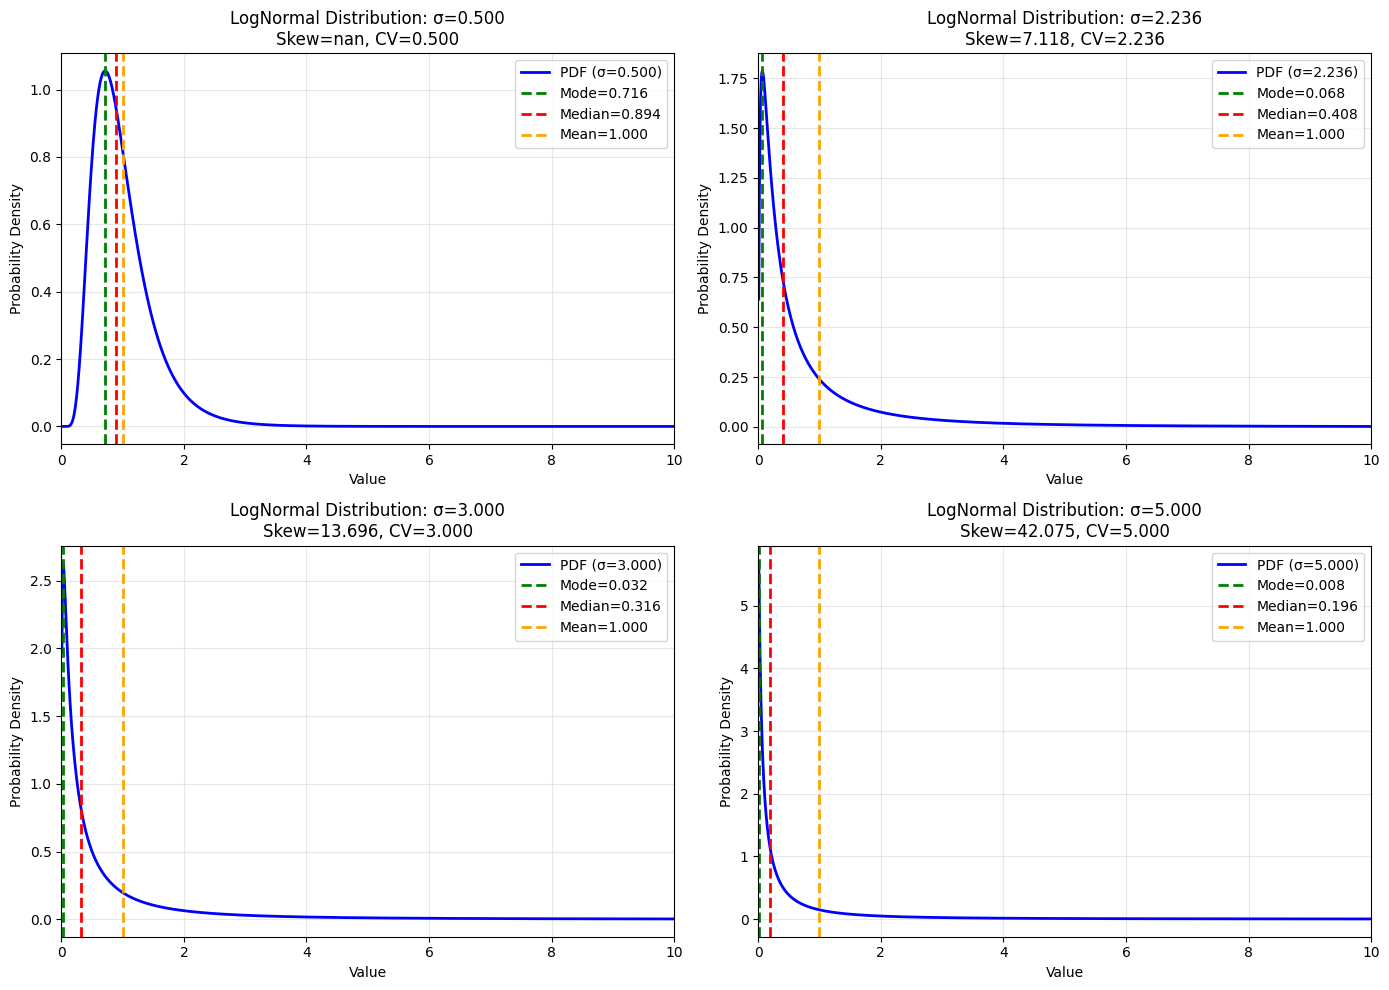

In [4]:
# Create PDFs for different sigma values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x = np.linspace(0, 10, 1000)

test_sigmas = [0.5, 2.236, 3.0, 5.0]

for idx, sigma in enumerate(test_sigmas):
    ax = axes[idx // 2, idx % 2]
    
    ln = LogNormalPDF(mu=mu_fixed, sigma=sigma, gstat=False)
    pdf = ln.pdf(x, mu=mu_fixed, sigma=sigma, gstat=False)
    
    ax.plot(x, pdf, 'b-', linewidth=2, label=f'PDF (σ={sigma:.3f})')
    ax.axvline(ln.mode, color='g', linestyle='--', linewidth=2, label=f'Mode={ln.mode:.3f}')
    ax.axvline(ln.median, color='r', linestyle='--', linewidth=2, label=f'Median={ln.median:.3f}')
    ax.axvline(mu_fixed, color='orange', linestyle='--', linewidth=2, label=f'Mean={mu_fixed:.3f}')
    
    ax.set_xlabel('Value')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'LogNormal Distribution: σ={sigma:.3f}\nSkew={ln.skew:.3f}, CV={sigma/mu_fixed:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

## 4. Common Values in Literature

From the codebase and configs, we see several common sigma values:
- **2.0**: Used in cloud-params.ini and test configs
- **√5 ≈ 2.236**: Default in LogNormalFractalCube class
- **2.5**: Often used for cloud/turbulence simulations

In [5]:
# Analyze common values
common_sigmas = {
    '2.0 (cloud-params)': 2.0,
    '√5 ≈ 2.236 (default)': np.sqrt(5.),
    '2.5 (typical turbulence)': 2.5,
}

print("Common Sigma Values Analysis:")
print("=" * 80)

for name, sigma in common_sigmas.items():
    ln = LogNormalPDF(mu=mu_fixed, sigma=sigma, gstat=False)
    print(f"\n{name}:")
    print(f"  σ = {sigma:.4f}")
    print(f"  Mode = {ln.mode:.4f}, Median = {ln.median:.4f}")
    print(f"  Gaussian: μ_g = {ln.mu_g:.4f}, σ_g = {ln.sigma_g:.4f}")
    print(f"  Skewness = {ln.skew:.4f} (controls asymmetry)")
    print(f"  CV = {sigma/mu_fixed:.3f} ({sigma/mu_fixed*100:.1f}%)")

Common Sigma Values Analysis:

2.0 (cloud-params):
  σ = 2.0000
  Mode = 0.0894, Median = 0.4472
  Gaussian: μ_g = -0.8047, σ_g = 1.2686
  Skewness = 5.4647 (controls asymmetry)
  CV = 2.000 (200.0%)

√5 ≈ 2.236 (default):
  σ = 2.2361
  Mode = 0.0680, Median = 0.4082
  Gaussian: μ_g = -0.8959, σ_g = 1.3386
  Skewness = 7.1185 (controls asymmetry)
  CV = 2.236 (223.6%)

2.5 (typical turbulence):
  σ = 2.5000
  Mode = 0.0512, Median = 0.3714
  Gaussian: μ_g = -0.9905, σ_g = 1.4075
  Skewness = 9.1617 (controls asymmetry)
  CV = 2.500 (250.0%)


## 5. Practical Limits

### Very Small Sigma (< 0.5)
- Distribution becomes narrow, approaching a delta function
- Generates homogeneous-looking images
- Limited diversity for ML training

### Medium Sigma (0.5 - 3.0)
- Balanced spread with identifiable mode
- Good for realistic cloud/turbulence simulations
- Provides variety while maintaining physical plausibility

### Large Sigma (> 5.0)
- Heavy right tail, extreme values dominate
- May produce unrealistic distributions
- Numerical instability possible

Let's test numerical stability:

Unstable sigma values: 19
  σ=0.1000: NaN/Inf detected
  σ=0.1151: NaN/Inf detected
  σ=0.1326: NaN/Inf detected
  σ=0.1526: NaN/Inf detected
  σ=0.1758: NaN/Inf detected


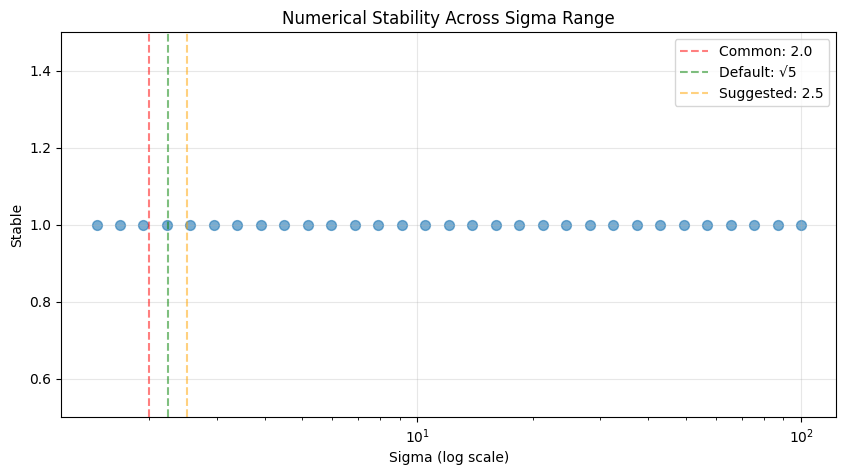

In [6]:
# Test numerical stability across wide range
test_range = np.logspace(-1, 2, 50)  # 0.1 to 100
stability_results = []

for sigma in test_range:
    try:
        ln = LogNormalPDF(mu=mu_fixed, sigma=sigma, gstat=False)
        
        # Check for NaN/Inf
        has_nan = np.isnan([ln.mu_g, ln.sigma_g, ln.skew, ln.kurt, ln.mode, ln.median]).any()
        has_inf = np.isinf([ln.mu_g, ln.sigma_g, ln.skew, ln.kurt, ln.mode, ln.median]).any()
        
        stability_results.append({
            'sigma': sigma,
            'stable': not (has_nan or has_inf),
            'has_nan': has_nan,
            'has_inf': has_inf
        })
    except Exception as e:
        stability_results.append({
            'sigma': sigma,
            'stable': False,
            'error': str(e)[:50]
        })

# Summary
unstable = [r for r in stability_results if not r['stable']]
if unstable:
    print(f"Unstable sigma values: {len(unstable)}")
    for r in unstable[:5]:
        print(f"  σ={r['sigma']:.4f}: {r.get('error', 'NaN/Inf detected')}")
else:
    print(f"All {len(stability_results)} sigma values are numerically stable")

# Plot stability
stable_sigmas = [r['sigma'] for r in stability_results if r['stable']]
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(stable_sigmas, [1]*len(stable_sigmas), alpha=0.6, s=50)
ax.set_xscale('log')
ax.set_xlabel('Sigma (log scale)')
ax.set_ylabel('Stable')
ax.set_title('Numerical Stability Across Sigma Range')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.5, 1.5)
ax.axvline(2.0, color='r', linestyle='--', alpha=0.5, label='Common: 2.0')
ax.axvline(np.sqrt(5), color='g', linestyle='--', alpha=0.5, label='Default: √5')
ax.axvline(2.5, color='orange', linestyle='--', alpha=0.5, label='Suggested: 2.5')
ax.legend()
plt.show()

## 6. Recommendation for Flexible Dataset Generation

In [7]:
# Recommended ranges
recommendations = {
    'Conservative': (1.5, 2.5),
    'Standard': (2.0, 3.0),
    'Aggressive': (2.0, 5.0),
    'Exploration': (0.5, 5.0),
}

print("\nRECOMMENDED SIGMA RANGES FOR FLEXIBLE GENERATION:")
print("=" * 80)

for profile, (low, high) in recommendations.items():
    ln_low = LogNormalPDF(mu=mu_fixed, sigma=low, gstat=False)
    ln_high = LogNormalPDF(mu=mu_fixed, sigma=high, gstat=False)
    
    print(f"\n{profile}: [{low}, {high}]")
    print(f"  CV range: [{low/mu_fixed:.3f}, {high/mu_fixed:.3f}] ({low*100/mu_fixed:.0f}%-{high*100/mu_fixed:.0f}%)")
    print(f"  Mode range: [{ln_low.mode:.4f}, {ln_high.mode:.4f}]")
    print(f"  Skewness range: [{ln_low.skew:.4f}, {ln_high.skew:.4f}]")
    print(f"  Use case: ", end="")
    
    if profile == 'Conservative':
        print("Similar clouds, minimal noise - good for validation")
    elif profile == 'Standard':
        print("Realistic cloud physics - recommended for training")
    elif profile == 'Aggressive':
        print("High diversity - good for robustness testing")
    else:
        print("Full range exploration - research/sensitivity analysis")


RECOMMENDED SIGMA RANGES FOR FLEXIBLE GENERATION:

Conservative: [1.5, 2.5]
  CV range: [1.500, 2.500] (150%-250%)
  Mode range: [0.1707, 0.0512]
  Skewness range: [2.2190, 9.1617]
  Use case: Similar clouds, minimal noise - good for validation

Standard: [2.0, 3.0]
  CV range: [2.000, 3.000] (200%-300%)
  Mode range: [0.0894, 0.0316]
  Skewness range: [5.4647, 13.6957]
  Use case: Realistic cloud physics - recommended for training

Aggressive: [2.0, 5.0]
  CV range: [2.000, 5.000] (200%-500%)
  Mode range: [0.0894, 0.0075]
  Skewness range: [5.4647, 42.0755]
  Use case: High diversity - good for robustness testing

Exploration: [0.5, 5.0]
  CV range: [0.500, 5.000] (50%-500%)
  Mode range: [0.7155, 0.0075]
  Skewness range: [nan, 42.0755]
  Use case: Full range exploration - research/sensitivity analysis


## Summary and Final Recommendation

### Key Findings:
1. **Sigma represents the standard deviation of the lognormal distribution**
2. **Physically**: Higher sigma = more spread/variance in the field, resembling more turbulent clouds
3. **Common values**: 2.0, √5≈2.236 (default), 2.5 - all in the 2.0-3.0 range
4. **No mathematical upper limit**, but practical limits exist for realism
5. **Numerically stable** across 0.1-100+ range

### Recommended Range for Flexible Generation:
**σ ∈ [2.0, 2.5]** - This range:
- Maintains physical plausibility
- Provides diversity (CV = 2.0-2.5)
- Matches existing literature values
- Avoids extreme/unrealistic distributions
- Is numerically stable

**Alternative: [1.5, 3.0]** if exploring wider diversity is needed for ML robustness